In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max.rows',130)
pd.set_option('display.max.columns',130)
pd.set_option('float_format', '{:.2f}'.format)

In [58]:
df = pd.read_csv('../data/raw/bank-additional-full.csv', sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no


In [59]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

In [60]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [62]:
for col in categorical_cols:
    print(f"Value Counts for {col}:")
    print(df[col].unique())
    print()

Value Counts for job:
['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']

Value Counts for marital:
['married' 'single' 'divorced' 'unknown']

Value Counts for education:
['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']

Value Counts for default:
['no' 'unknown' 'yes']

Value Counts for housing:
['no' 'yes' 'unknown']

Value Counts for loan:
['no' 'yes' 'unknown']

Value Counts for contact:
['telephone' 'cellular']

Value Counts for month:
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']

Value Counts for day_of_week:
['mon' 'tue' 'wed' 'thu' 'fri']

Value Counts for poutcome:
['nonexistent' 'failure' 'success']

Value Counts for y:
['no' 'yes']



In [63]:
for col in categorical_cols:
    print(f"Value Counts for {col}:")
    print(df[col].value_counts(normalize=True) * 100)
    print()

Value Counts for job:
job
admin.          25.30
blue-collar     22.47
technician      16.37
services         9.64
management       7.10
retired          4.18
entrepreneur     3.54
self-employed    3.45
housemaid        2.57
unemployed       2.46
student          2.12
unknown          0.80
Name: proportion, dtype: float64

Value Counts for marital:
marital
married    60.52
single     28.09
divorced   11.20
unknown     0.19
Name: proportion, dtype: float64

Value Counts for education:
education
university.degree     29.54
high.school           23.10
basic.9y              14.68
professional.course   12.73
basic.4y              10.14
basic.6y               5.56
unknown                4.20
illiterate             0.04
Name: proportion, dtype: float64

Value Counts for default:
default
no        79.12
unknown   20.87
yes        0.01
Name: proportion, dtype: float64

Value Counts for housing:
housing
yes       52.38
no        45.21
unknown    2.40
Name: proportion, dtype: float64

Value Counts

In [64]:
for col in categorical_cols:
    print(f"Value Counts for {col}:")
    print(df[col].value_counts())
    print()

Value Counts for job:
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

Value Counts for marital:
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

Value Counts for education:
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

Value Counts for default:
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

Value Counts for housing:
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

Value Counts for 

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'campaign'}>],
       [<Axes: title={'center': 'pdays'}>,
        <Axes: title={'center': 'previous'}>,
        <Axes: title={'center': 'emp.var.rate'}>],
       [<Axes: title={'center': 'cons.price.idx'}>,
        <Axes: title={'center': 'cons.conf.idx'}>,
        <Axes: title={'center': 'euribor3m'}>],
       [<Axes: title={'center': 'nr.employed'}>, <Axes: >, <Axes: >]],
      dtype=object)

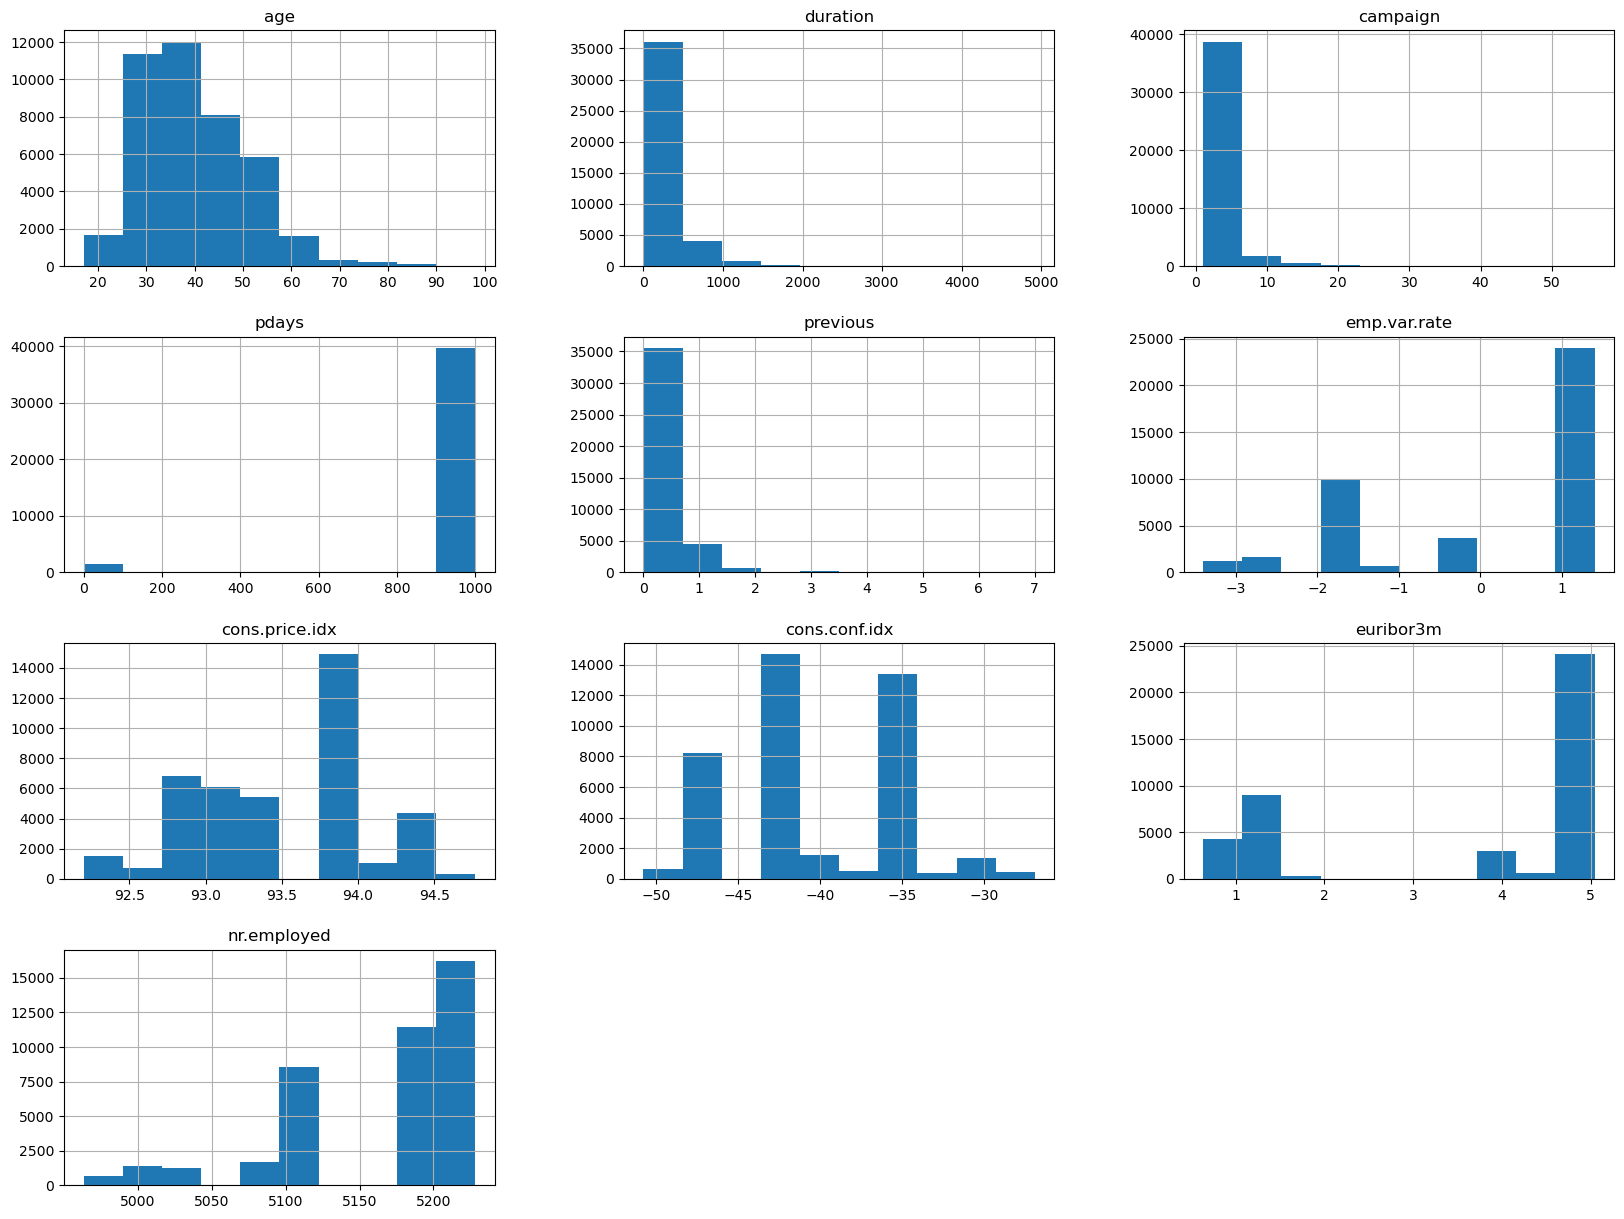

In [65]:
df.hist(figsize=(20, 15))

In [66]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no


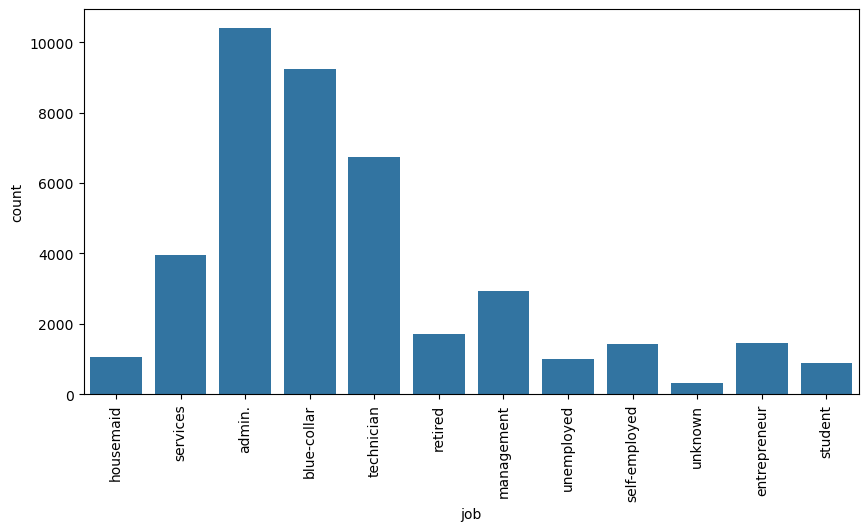

In [67]:
plt.figure(figsize = (10,5))
sns.countplot(data = df, x = "job")
plt.xticks(rotation = 90)
plt.show()

In [68]:

def bi_cat_countplot(df, column, hue_column):
    unique_hue_values = df[hue_column].unique()
    fig, axes = plt.subplots(nrows=1, ncols=2)
    fig.set_size_inches(14,6)

    pltname = f'Нормалізований розподіл значень за категорією: {column}'
    proportions = df.groupby(hue_column)[column].value_counts(normalize=True)
    proportions = (proportions*100).round(2)
    ax = proportions.unstack(hue_column).sort_values(
        by=unique_hue_values[0], ascending=False
        ).plot.bar(ax=axes[0], title=pltname)

    # анотація значень в барплоті
    for container in ax.containers:
        ax.bar_label(container, fmt='{:,.1f}%')

    pltname = f'Кількість даних за категорією: {column}'
    counts = df.groupby(hue_column)[column].value_counts()
    ax = counts.unstack(hue_column).sort_values(
        by=unique_hue_values[0], ascending=False
        ).plot.bar(ax=axes[1], title=pltname)

    for container in ax.containers:
      ax.bar_label(container)


def uni_cat_target_compare(df, column, hue_column='TARGET'):
    bi_cat_countplot(df, column, hue_column=hue_column)


def bi_countplot_target(df0, df1, column, hue_column):
  pltname = 'Клієнт зі складнощами щодо платності'
  print(pltname.upper())
  bi_cat_countplot(df1, column, hue_column)
  plt.show()

  pltname = 'Клієнти зі своєчасними платежами'
  print(pltname.upper())
  bi_cat_countplot(df0, column, hue_column)
  plt.show()


In [69]:
bins = [0, 18, 35, 50, 65, np.inf]  
labels = ['Child','Young Adult', 'Adult', 'Middle Age', 'Senior'] 

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False,include_lowest=True)

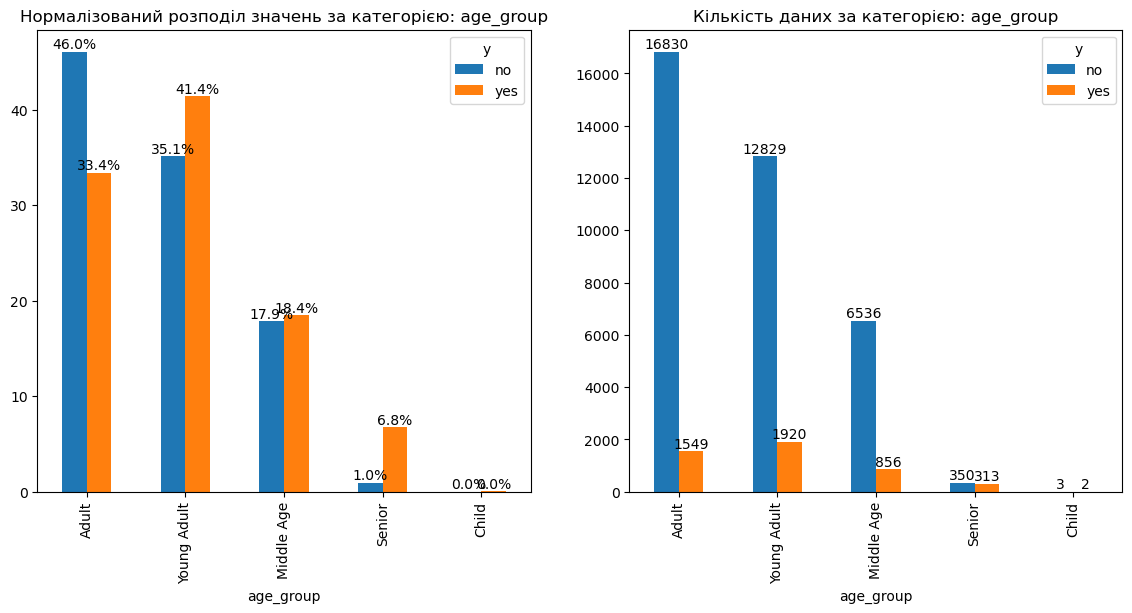

In [70]:
uni_cat_target_compare(df, 'age_group','y')

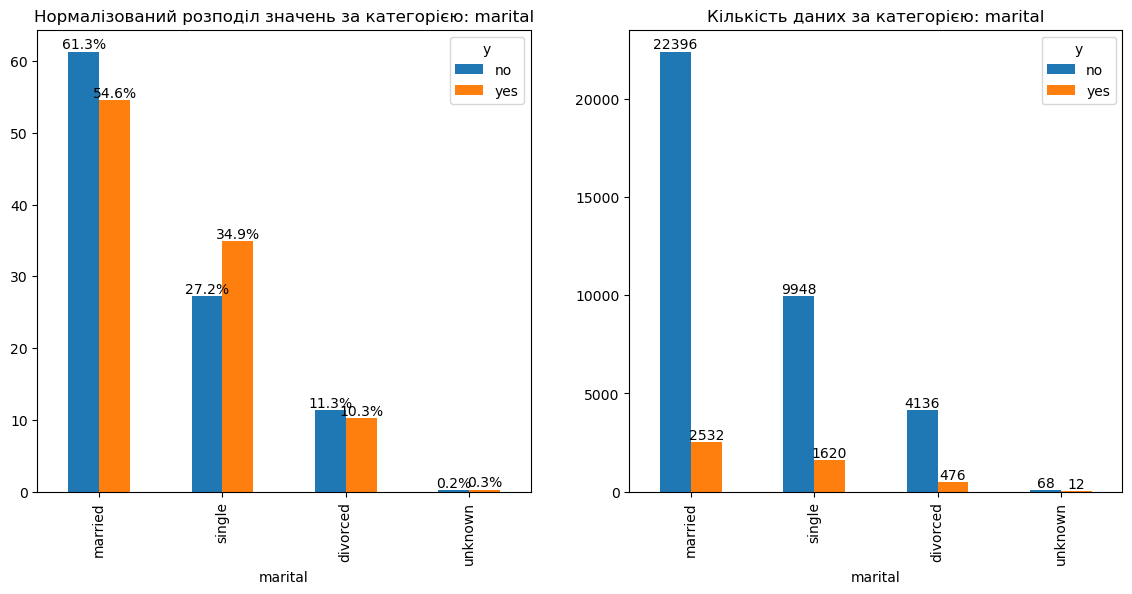

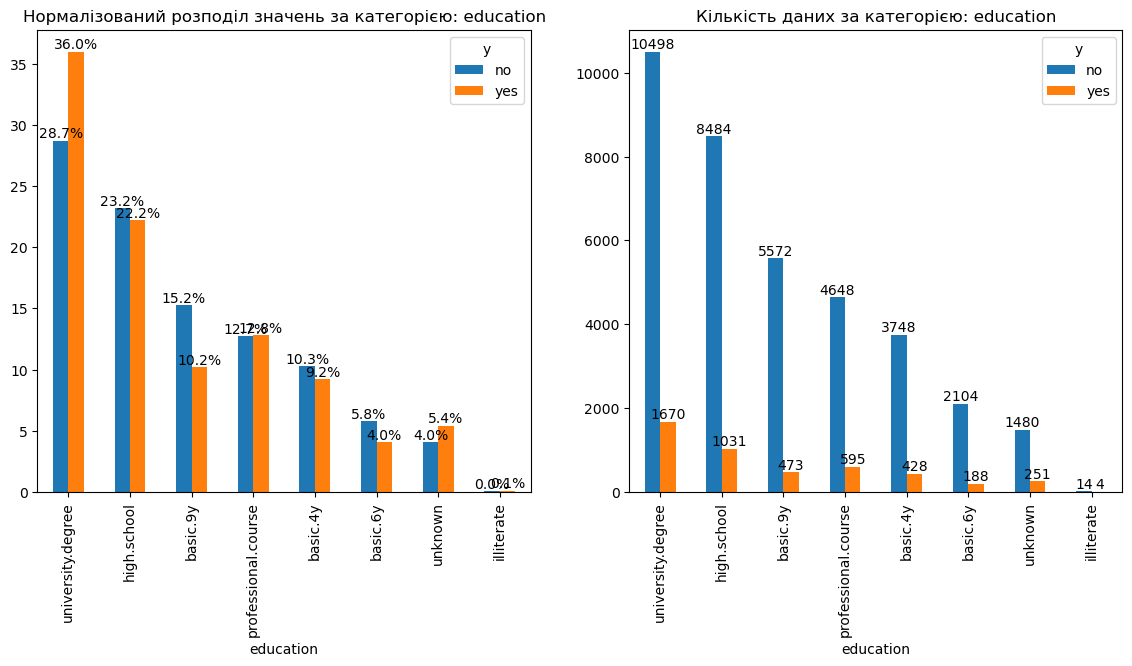

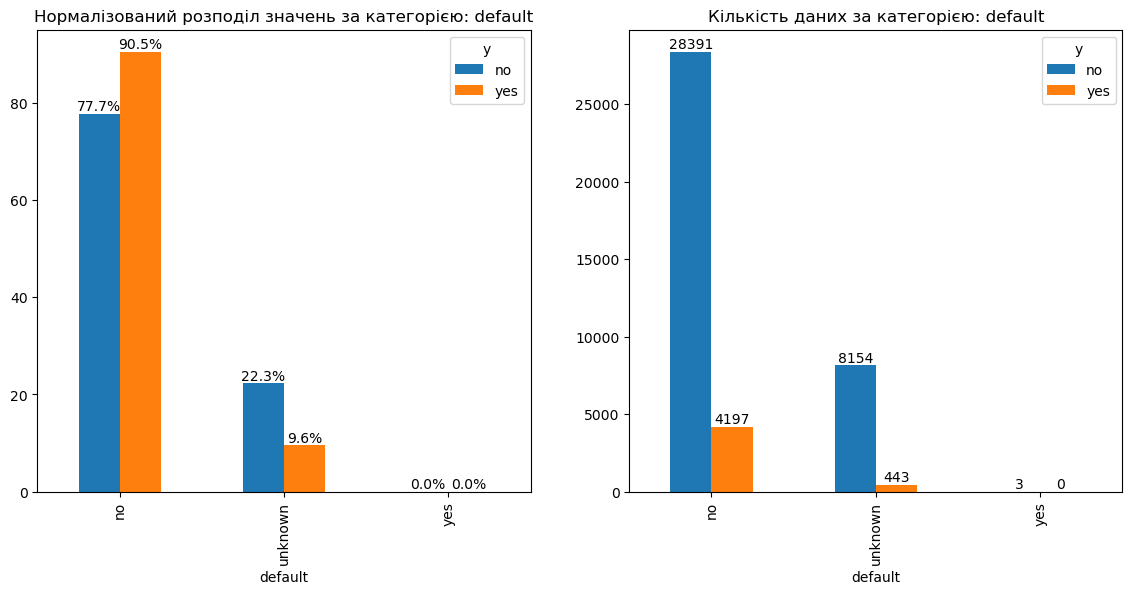

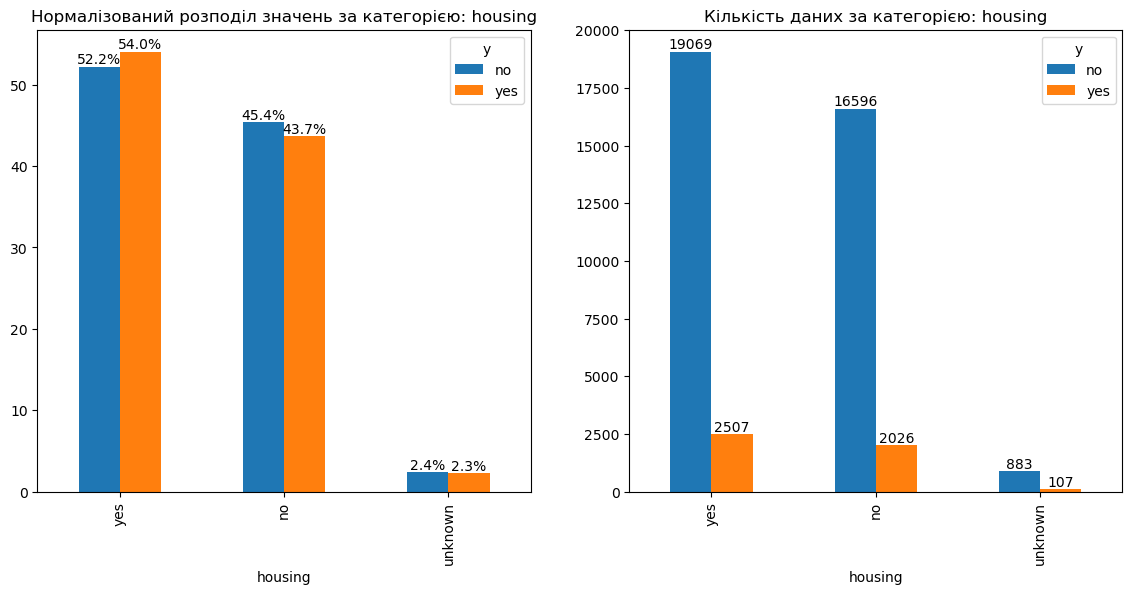

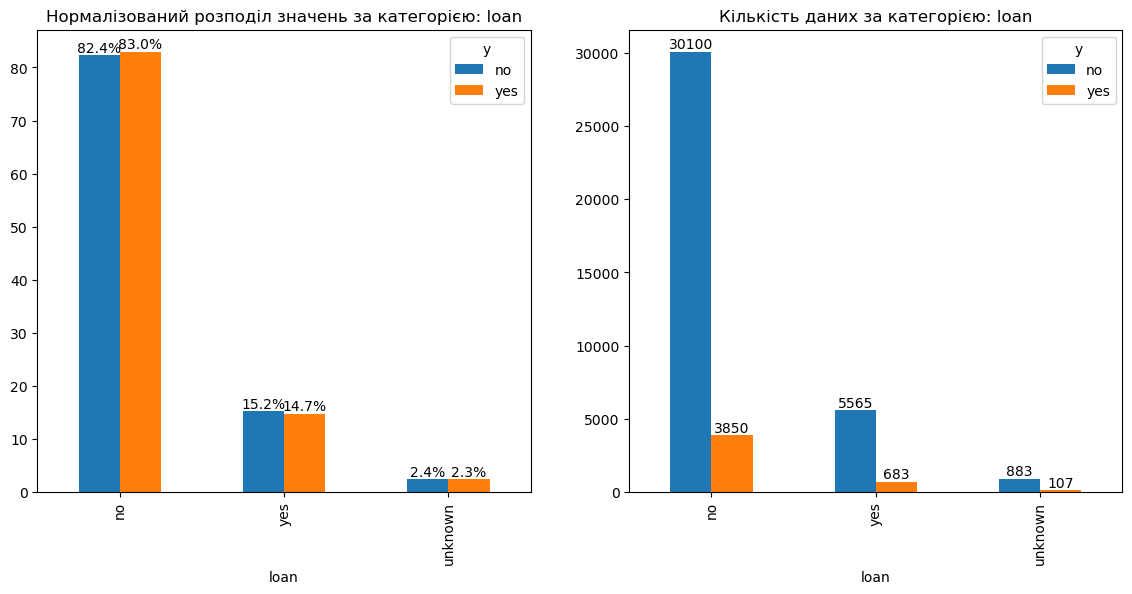

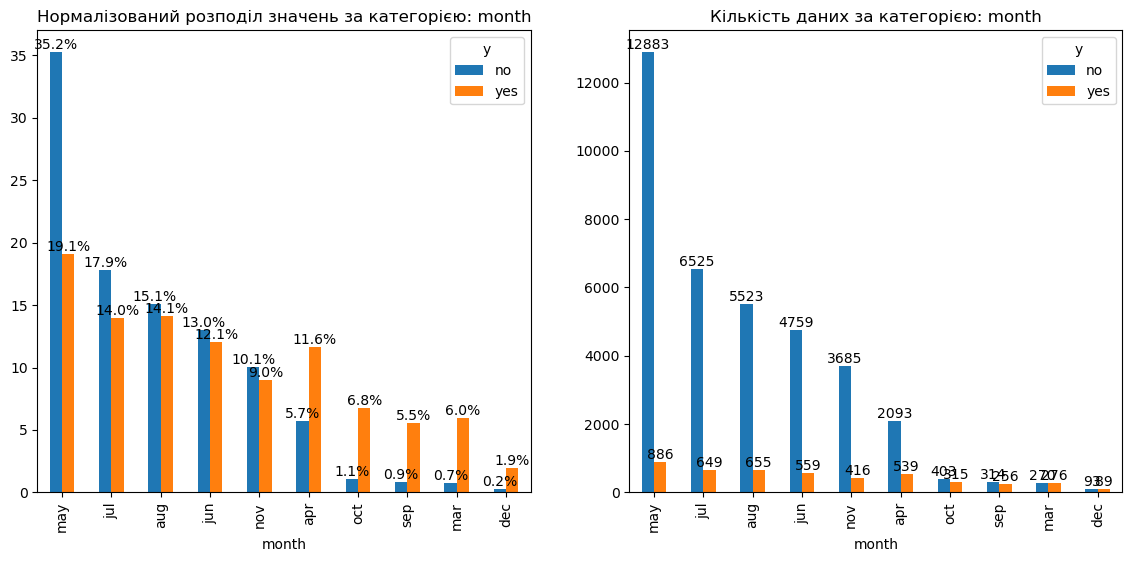

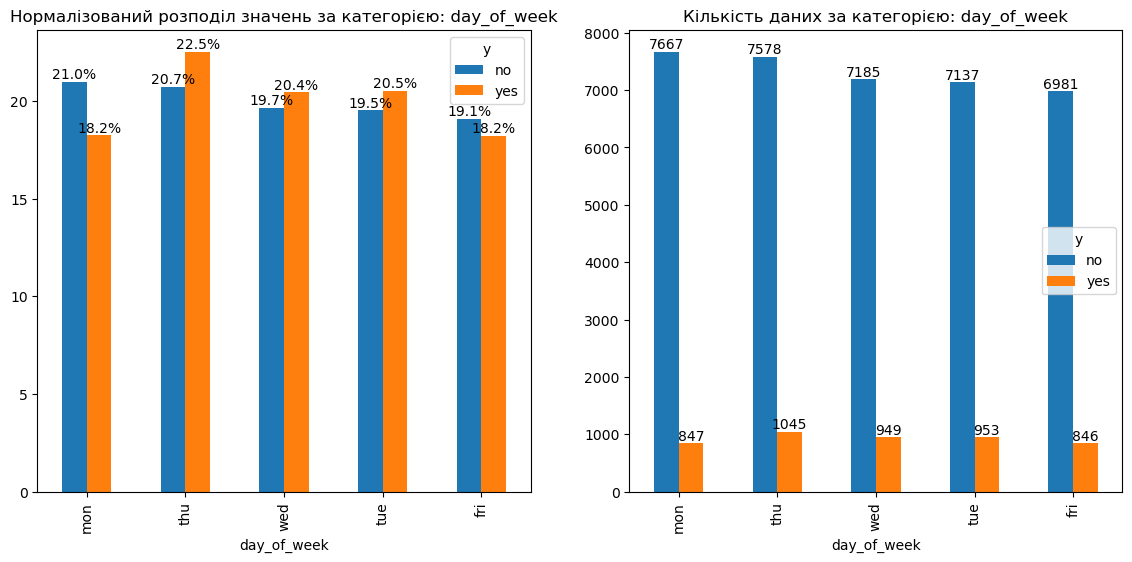

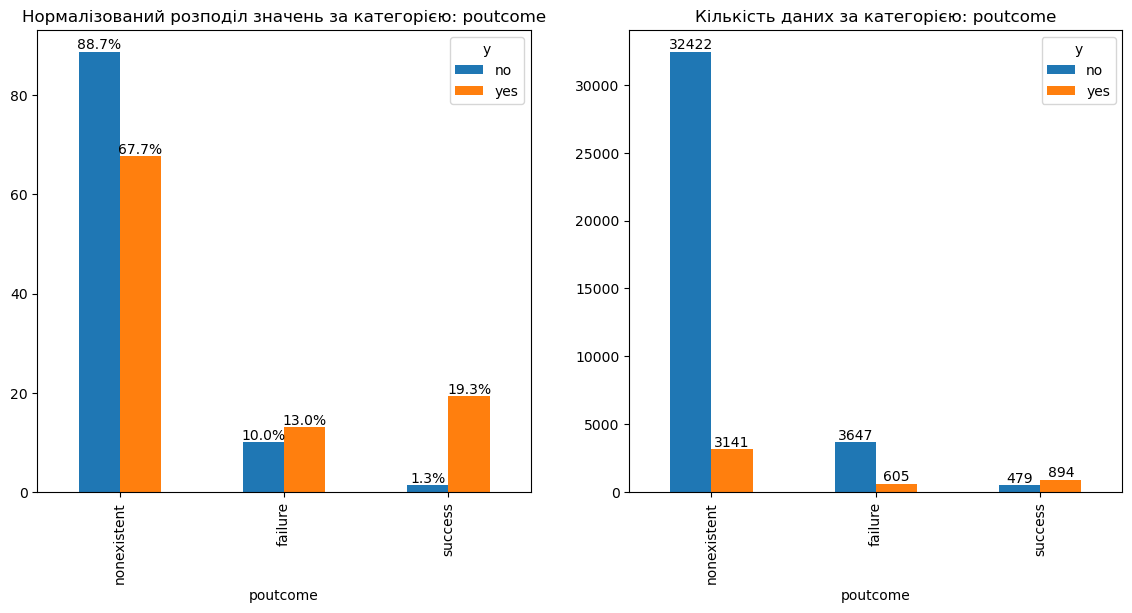

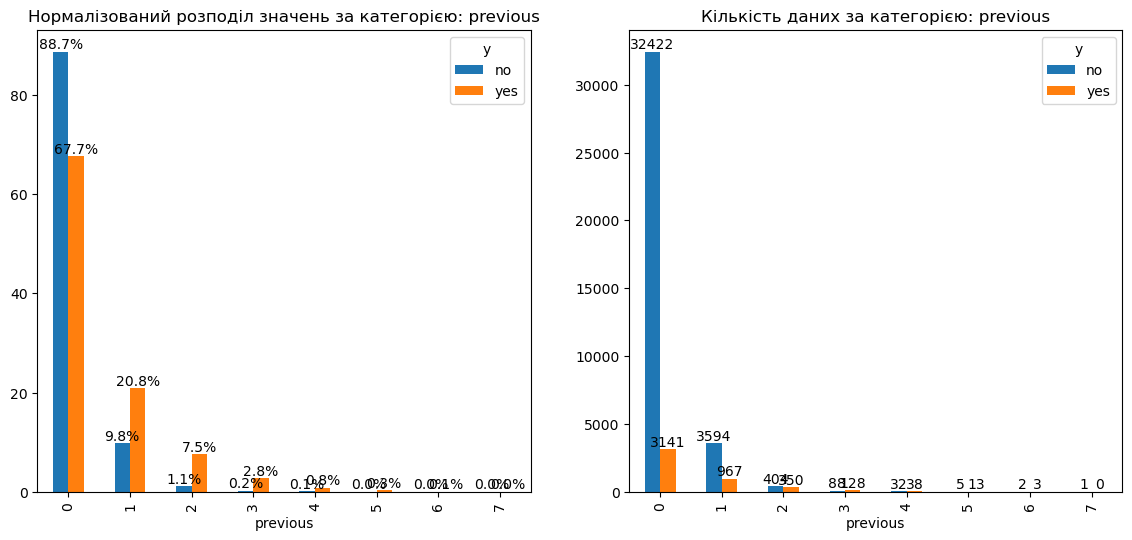

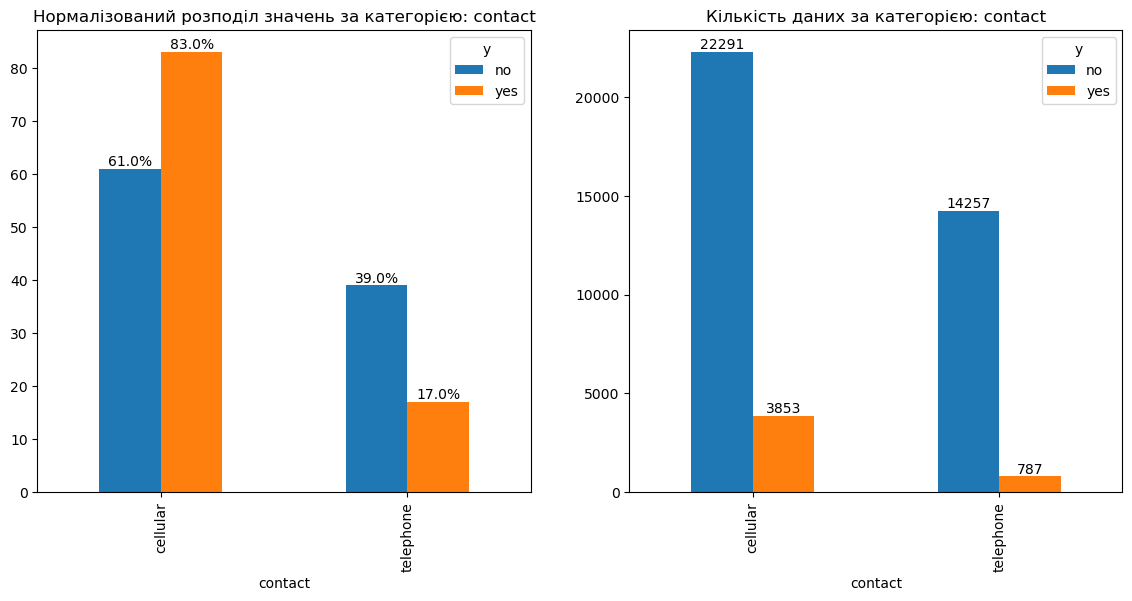

In [71]:
for column in ['marital', 'education', 'default', 'housing', 'loan',  'month', 'day_of_week', 'poutcome','previous','contact']:
    uni_cat_target_compare(df, column,'y')

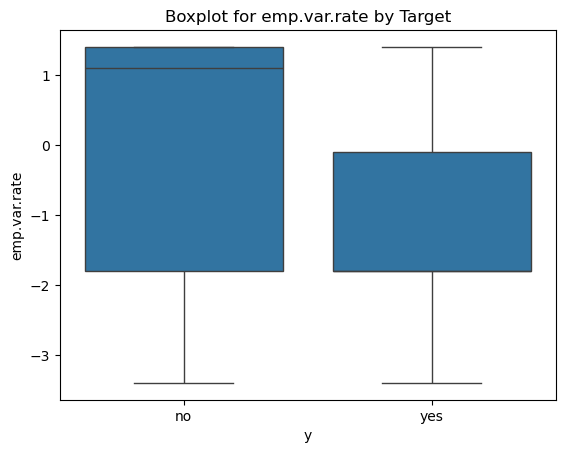

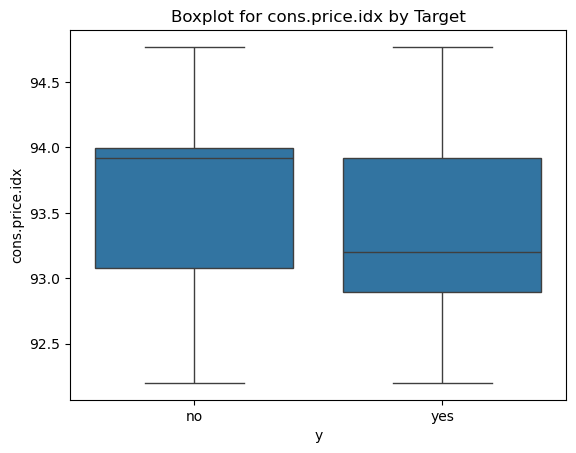

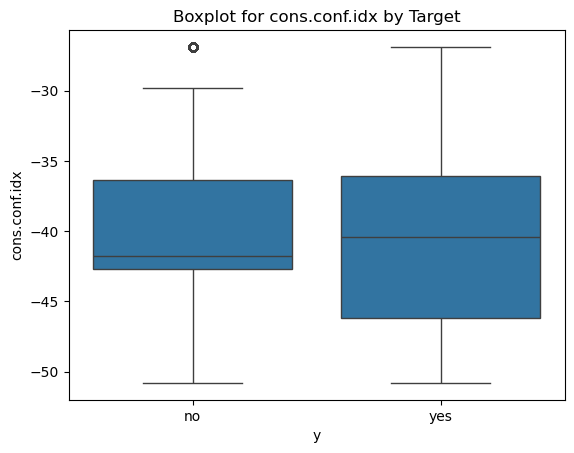

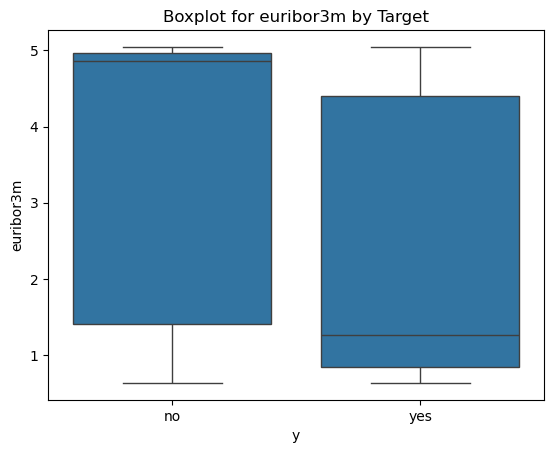

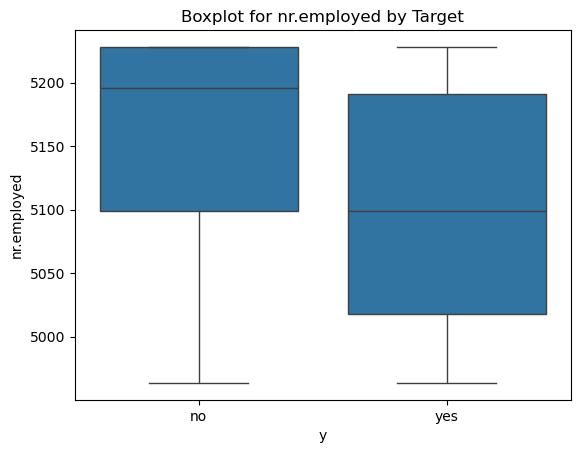

In [72]:
for column in ['emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']:
    sns.boxplot(x='y', y=column, data=df)
    plt.title(f'Boxplot for {column} by Target')
    plt.show()  

In [73]:
def draw_boxplot(df, categorical, continuous, max_continuous, title, hue_column, subplot_position):
    """
    Малює блок-діаграму для заданого DataFrame, категоріальної та неперервної змінної.
    """
    plt.subplot(1, 2, subplot_position)
    plt.title(title)
    red_diamond = dict(markerfacecolor='r', marker='D')
    sns.boxplot(x=categorical,
                y=df[df[continuous] < max_continuous][continuous],
                data=df,
                flierprops=red_diamond,
                order=sorted(df[categorical].unique(), reverse=True),
                hue=hue_column, hue_order=sorted(df[hue_column].unique(), reverse=True))
    plt.ticklabel_format(style='plain', axis='y')
    plt.xticks(rotation=90)

def bi_boxplot(categorical, continuous, max_continuous1, hue_column):
    """
    Створює паралельні блок-діаграми для двох груп, визначених у наборі даних, на основі
    категоріальної та неперервної змінної, виділяючи відмінності за допомогою відтінків.
    """
    plt.figure(figsize=(16, 10))

    # Графік для першо групи "Труднощі з платежами" (Payment Difficulties)
    draw_boxplot(df, categorical, continuous, max_continuous1, 'Payment Difficulties', hue_column, 1)

    plt.tight_layout(pad=4)
    plt.show()

def outlier_range(dataset,column):
    Q1 = dataset[column].quantile(0.25)
    Q3 = dataset[column].quantile(0.75)
    IQR = Q3 - Q1
    Min_value = (Q1 - 1.5 * IQR)
    Max_value = (Q3 + 1.5 * IQR)
    return Max_value

In [74]:
max_value_duration = outlier_range(df,'duration')
max_value_duration

np.float64(644.5)

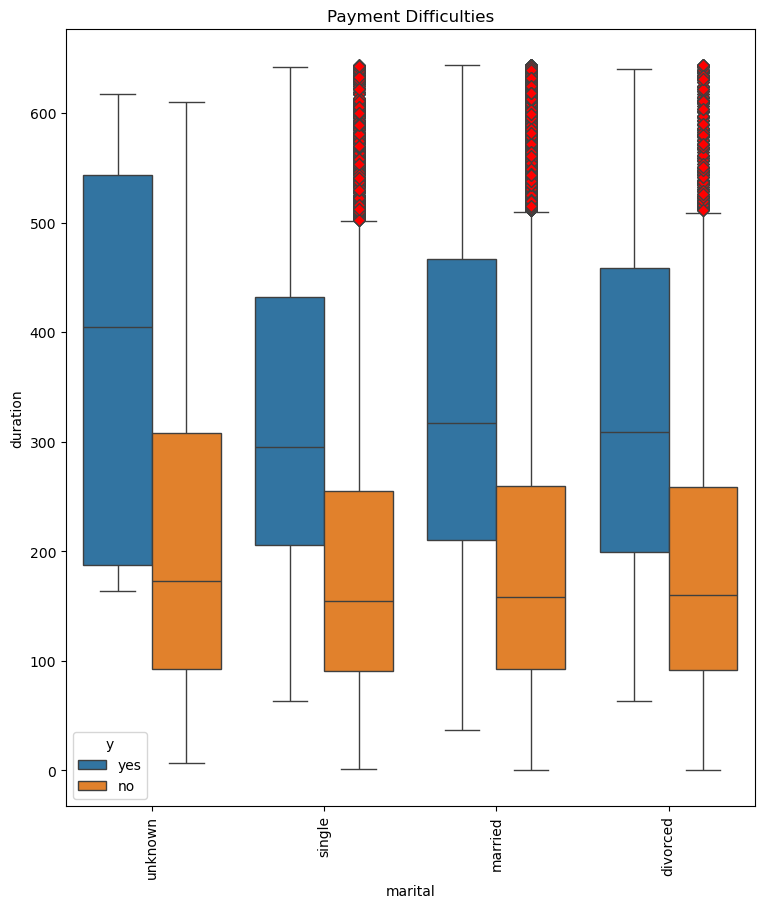

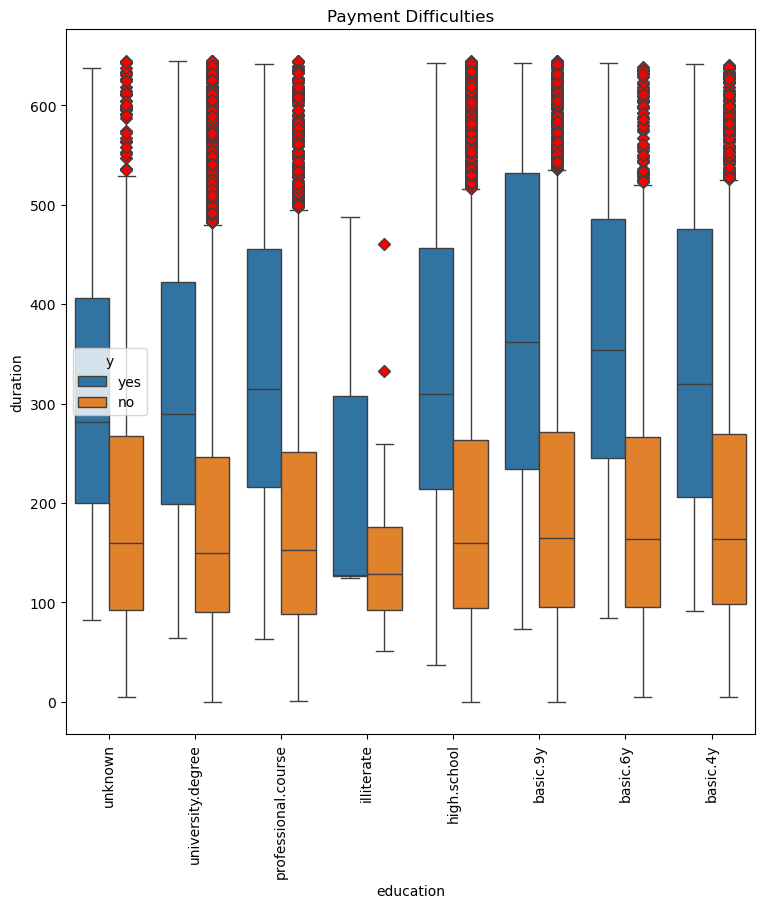

In [75]:
for column in ['marital', 'education']:
    bi_boxplot(column,'duration',max_value_duration, 'y')

In [76]:
df['y'] = df['y'].map({'yes': 1, 'no': 0}).astype(int)

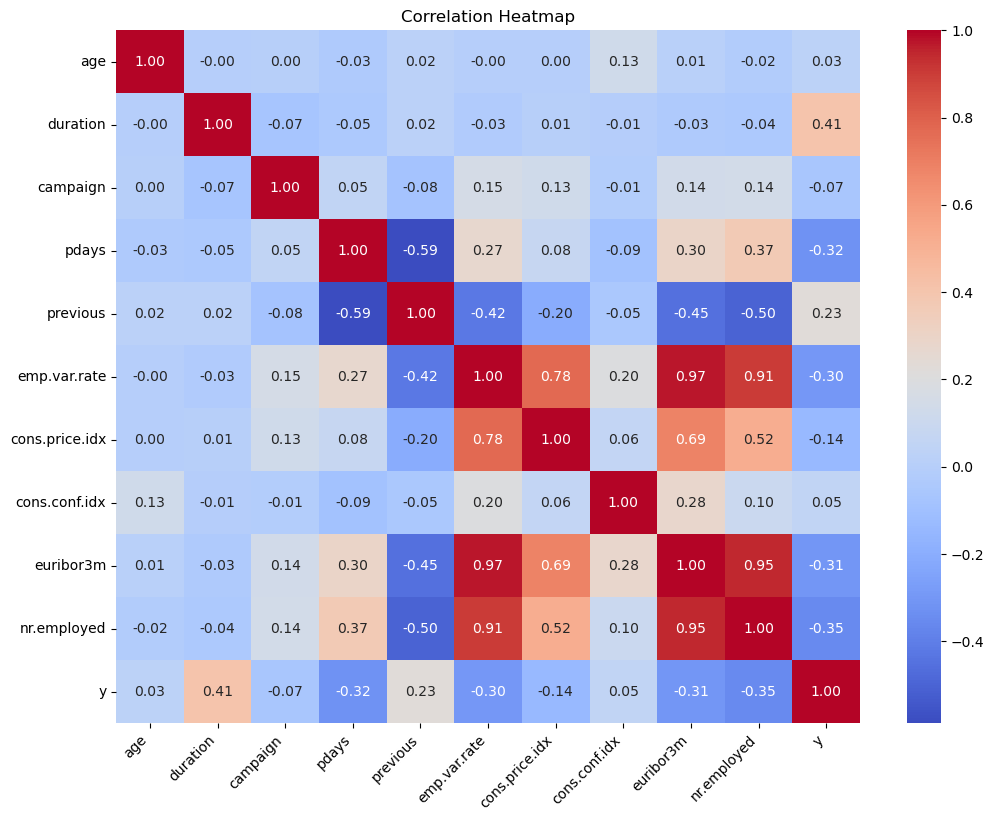

In [79]:
import plotly.express as px
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12, 9))  # big enough for 20 cols
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Correlation Heatmap")
plt.show()

In [78]:
df.groupby('job')['previous'].transform(lambda x: (x>0).mean())

0       0.11
1       0.13
2       0.13
3       0.15
4       0.13
        ... 
41183   0.23
41184   0.11
41185   0.23
41186   0.12
41187   0.23
Name: previous, Length: 41188, dtype: float64